# UR3e Reach — Setup, Simulation Walkthrough & Reward Tuning

This notebook walks through:

1. Picking the right kernel (this folder has no Python env of its own)
2. Registering and building the `Mjlab-UR3e-Reach` task
3. Resetting the environment and looking at it (offscreen render)
4. Running a short rollout
5. **The reward deep-dive** — inspecting each reward term live, and changing/adding
   terms *without* editing `ur3e_reach_env_cfg.py` every time you want to try something

This notebook lives inside the `ur3e/` package itself
([`ur3e_reach_env_cfg.py`](ur3e_reach_env_cfg.py), [`commands.py`](commands.py)) and
imports it directly — it never touches the other copy of this task under
`my_mjlab_project`, so anything you do here only affects this folder.

## All run settings, at a glance

Quick reference -- the "why" behind the starred rows is in **Big picture** right
below, and the full reward breakdown is in section 5.

**Physics / episode (`get_ur3e_reach_env_cfg()` in [`ur3e_reach_env_cfg.py`](ur3e_reach_env_cfg.py))**

| setting | value | what it controls |
|---|---|---|
| `sim.mujoco.timestep` | `0.01s` | physics integration step |
| `sim.mujoco.integrator` | `"implicitfast"` | MuJoCo integrator; explicit here because this is the only place it actually takes effect (see naming reference below) |
| `decimation` \* | `10` | physics steps per policy step -> `0.1s`/policy step |
| `episode_length_s` \* | `22.0s` (220 steps) | episode length before time-out truncation |
| `scene.num_envs` \* | `512` (train) / `1` (play) | parallel environments (override with `--num-envs` on the CLI, or `cfg.scene.num_envs =` in a notebook) |
| `scene.env_spacing` | `2.0` | distance between parallel envs in the viewer (visual only, doesn't affect physics) |
| action scale | `0.08 rad` | max joint-angle delta per policy step (`arm_joints` action term) |
| `enable_collision_penalty` | `True` | whether self/table collision sensors + reward terms are attached at all |
| `use_velocity_clamp` | `False` | swaps in a clamped action variant for visual validation only, not training (see `Mjlab-UR3e-Reach-ClampedPlay`) |

**Training (`ur3e_reach_ppo_runner_cfg()` in [`__init__.py`](__init__.py))**

| setting | value | what it controls |
|---|---|---|
| `experiment_name` | `"ur3e_reach"` | checkpoint/log folder name under `logs/rsl_rl/` |
| `max_iterations` | `2_000` | training loop length (PPO update iterations) |
| `save_interval` | `50` | checkpoint save frequency, in iterations |
| `num_steps_per_env` | `24` | rollout length per env before each PPO update -> `num_envs * num_steps_per_env` transitions/update |
| `hidden_dims` (actor + critic) | `(128, 128)` | policy/value network size -- small on purpose, see Big picture |
| `activation` | `"elu"` | network activation function |
| `obs_normalization` | `True` | running mean/std normalization on observations |
| `distribution_cfg` | Gaussian, `init_std=1.0`, scalar std | action distribution the policy samples from |
| `clip_param` | `0.2` | PPO's policy-update clipping threshold |
| `entropy_coef` | `0.02` | exploration bonus weight (raised from `0.005`, see code comment) |
| `value_loss_coef` | `1.0` | critic loss weight |
| `use_clipped_value_loss` | `True` | clips the critic loss the same way as the policy loss |
| `num_learning_epochs` | `5` | passes over each rollout batch per update |
| `num_mini_batches` | `4` | mini-batches per epoch |
| `learning_rate` | `1.0e-3` | initial optimizer learning rate |
| `schedule` | `"adaptive"` | learning-rate schedule (adjusts based on KL divergence) |
| `gamma` | `0.99` | discount factor |
| `lam` | `0.95` | GAE (generalized advantage estimation) lambda |
| `desired_kl` | `0.01` | target KL divergence for the adaptive schedule |
| `max_grad_norm` | `1.0` | gradient clipping threshold |

\* discussed in **Big picture** below.

## Big picture: what this sets up, and why

This section is a map of the choices baked into this task, before you run anything.
Skip it if you just want to run cells; come back to it when something's confusing.

### What's actually being trained

A policy that outputs 6 joint-angle *deltas* (not absolute positions) for a UR3e
arm, once every 0.1s, so the end-effector reaches a randomly placed target. Training
uses reinforcement learning (RL) — specifically **PPO** (Proximal Policy
Optimization, an on-policy RL algorithm) via **RSL-RL** (the RL training library
this repo uses).

**PPO**, concretely: collect a batch of experience with the *current* policy, then
update its weights to make good actions more likely — but cap how far any single
update is allowed to move the policy (the "proximal"/clipping part, `clip_param=0.2`
in this repo's config). Without that cap, one bad update from noisy data can wreck a
policy that took thousands of iterations to train; PPO trades a bit of learning
speed for a lot of stability, which is why it's the default choice for most
continuous-control robotics tasks like this one.

**"On-policy"** means the data used for each update must come from the *current*
version of the policy, not an older one. That's why each PPO update here consumes
exactly one freshly-collected rollout (`num_envs=512 × num_steps_per_env=24`
transitions, from the table above) and then discards it — it can't be reused for
the next update, since by then the policy's weights have changed and that data no
longer reflects what the *new* policy would actually do. This is the opposite of an
*off-policy* algorithm (e.g. SAC, DQN), which learns from a large replay buffer of
experience collected under many past versions of the policy — more
sample-efficient, but a different (and often less stable) set of trade-offs.
On-policy algorithms like PPO are typically paired with cheap, massively-parallel
simulation (the `num_envs` discussed next) specifically to make up for not being
able to reuse old data.

### "Environments" — why there are hundreds of them

RL needs lots of trial-and-error to learn from. Rather than simulate one arm, get
one outcome, update the policy, repeat, mjlab runs **many identical copies of the
same scene in parallel** — one arm + table + randomly-placed target per copy — all
stepped together on every `env.step()` call. Each copy is one "environment"
(`num_envs`). This is why `obs["actor"].shape` in cell 6 below is
`(num_envs, 18)`, not `(18,)`: one row per parallel copy.

**Why `512` and not more:** `num_envs=512` (the training default in
`get_ur3e_reach_env_cfg()`) is on the *small* end for GPU (graphics processing
unit)-parallel RL — locomotion tasks (quadrupeds, humanoids) commonly use
4096–16384+ parallel envs, because they need huge, varied batches (different
terrain, domain randomization, gait diversity) for a stable training signal. This
task is deliberately simple by comparison — 6 joints, 18 observation dims, no
domain randomization — so 512 envs × 24 steps/env (`num_steps_per_env` in
[`__init__.py`](__init__.py)) already gives PPO a big enough batch (~12k
transitions/rollout) without paying for compute this task doesn't need. That's also
why the policy/value networks are only 128×128 (see the naming reference below
`__init__.py` row) — a locomotion policy needs a much bigger net for a much
higher-dimensional observation space.

Both networks are plain **MLPs** (Multi-Layer Perceptrons — the simplest kind of
neural network: just a stack of fully-connected layers, each neuron wired to every
neuron in the previous layer, no convolution/attention/recurrence needed for a small
fixed-size input like this 18-dim observation). `hidden_dims=(128, 128)` means two
such layers of 128 neurons each, sitting between the 18 inputs and the 6 (actor) or
1 (critic) outputs. Between those layers, this config uses **ELU** (Exponential
Linear Unit) activation rather than the more common **ReLU** (Rectified Linear
Unit): ReLU is `max(0, x)` — a flat zero for any negative input, which can leave a
neuron permanently "dead" (stuck outputting zero, with zero gradient to ever recover)
if its input drifts negative during training. ELU instead curves smoothly toward a
small negative value as its input goes negative (`x` when `x > 0`, else a bounded
`α·(eˣ − 1)`), which keeps a small but non-zero gradient flowing even for negative
inputs, avoiding that dead-neuron failure mode — a reasonable, low-cost default
here, not something tuned specifically for this task.

One more wrinkle specific to *this* machine: the Warp backend prints `CUDA` (NVIDIA's
GPU computing platform) `not enabled in this build` / `Devices: "cpu": "arm"` on
reset (cell 6's output) — this Mac has no CUDA GPU, so all `num_envs` copies
simulate on the CPU (central processing unit — the regular, non-GPU processor), not
GPU. The `512` default still works here, it's just not getting the throughput
benefit it's sized for; section 2 below overrides it down to `4` for
interactive/CPU use, where it's fast enough to inspect live.

### Other choices, and why

- **Action space is relative, not absolute** (`target = current_qpos + action *
  0.08 rad`): matches how the real UR3e is actually commanded in deployment
  (`run_policy_loop`), so a trained policy transfers without retraining a different
  action interface.
- **`decimation=10`, physics `timestep=0.01s`** → one policy step = `0.1s` of sim
  time: chosen to match `step_duration` in the real deployment loop, not for
  simulation accuracy reasons — training at a different cadence than deployment
  would let the policy learn a control frequency it'll never actually get.
- **`episode_length_s=22.0`**: sized to fit about two *target resamples* per
  episode. The reach target isn't fixed for the whole episode -- it's a command
  term with `resampling_time_range=(9.0, 12.0)`
  ([`ur3e_reach_env_cfg.py:191`](ur3e_reach_env_cfg.py#L191)): every 9-12 seconds
  (randomized), the command manager silently swaps in a brand-new random target
  point within the reachable hemisphere, **without resetting the episode or the
  arm** -- same running episode, just a new goal to chase (you'll see the green
  target sphere jump in the section 3 render when this happens). A 22s episode
  gives the arm time to reach and settle at roughly two different targets before
  the episode ends, so the policy has to learn to generalize to arbitrary targets
  rather than memorize the path to whatever target it started with.
- **Reward is distance + success bonus + several penalty terms**, not just
  distance-to-target: the penalties (`ee_speed_limit`, `joint_vel_limit`,
  collisions, ...) exist because a policy trained on distance alone tends to find
  fast, jerky, or self-colliding solutions that minimize distance without being
  physically reasonable. Full breakdown and how to change them live in section 5.

See the collapsible **naming reference** cell after the imports below for exactly
where each of these settings and names is defined in code, and section 6 for how to
actually kick off a training run.

## A 60-second `uv` primer

Every venv/dependency reference below (and the kernel section right after this)
assumes some familiarity with [`uv`](https://docs.astral.sh/uv/), the tool managing
Python and its packages here instead of raw `pip`/`venv`. The short version:

- **`pyproject.toml`** — declares what your project depends on (e.g. `mjlab>=1.5.0`),
  same role as in any Python project.
- **`uv.lock`** — the *exact* resolved set of package versions (and hashes) that
  satisfies `pyproject.toml`, pinned down so a rebuild reproduces the same
  environment byte-for-byte. You don't hand-edit this file; `uv` regenerates it.
- **`uv sync`** — reads `uv.lock` and makes `.venv/` match it exactly: installs
  anything missing, removes anything that's not in the lock, and creates `.venv/`
  from scratch if it doesn't exist yet. This is the command to run after cloning a
  repo or wiping a venv.
- **`uv add <package>`** / **`uv add --upgrade-package <package>`** — adds a new
  dependency (or bumps an existing one) in `pyproject.toml`, re-resolves `uv.lock`,
  and syncs `.venv/` to match — the write path, as opposed to `sync`'s read-only
  reproduce path.
- **`uv run <cmd>`** — runs `<cmd>` using the project's `.venv` (auto-syncing first if
  the lock and venv have drifted), without needing to `source .venv/bin/activate`
  yourself.

One `uv.lock` = one project's dependency set. This repo's root `.venv` (used by this
notebook) and the separate `my_mjlab_project` project mentioned in section 6 each
have their own `pyproject.toml`/`uv.lock` — that's why section 6 talks about running
`uv sync` again there before training, even though this notebook's own venv is
already set up.

## 0. Kernel

This notebook runs on **`Simulations/.venv`** — the shared virtual environment for
everything under this repo (also used by `FallingBall` and `pendulum`). `mjlab`,
`torch`, and `mujoco-warp` are installed there, so `ur3e/` runs standalone with no
dependency on the `my_mjlab_project` folder or its own venv.

Select the **`.venv (3.14.4)`** kernel from the kernel picker (top-right of this
notebook) before running anything below — VS Code auto-detects this repo's `.venv`
directly, so there's no separate kernel name to register.

This repo now has its own `pyproject.toml` + `uv.lock` recording exactly what's
installed. If the venv is ever wiped or you're on a new machine, rebuild it with:

```bash
cd path/to/your/clone/of/Simulations
uv sync
```

then reselect `.venv (3.14.4)` in the kernel picker.

**Version note:** `mjlab==1.5.0` is pinned in `pyproject.toml` alongside
`mujoco==3.10.0`, `mujoco-warp==3.10.0.1`, `warp-lang==1.14.0`, and `torch==2.12.1`.
Newer patch releases of `mujoco-warp`/`warp-lang` (3.10.0.3 / 1.15.0, as of writing)
have a regression that breaks multi-env `reset()` -- if you ever bump these packages
(e.g. via `uv add --upgrade-package`) and cell 6 below throws `IndexError: index N is
out of bounds for dimension 0 with size 1`, that's why; pin back to the versions
above.

**F401 note:** the `# noqa: F401` on `import ur3e` in the next cell just tells the
linter not to flag that import as unused, since it's imported purely for the side
effect of registering the task, not for any name accessed off `ur3e.*`.

In [ ]:
import sys
from pathlib import Path

# Jupyter's default cwd is this notebook's own folder (`ur3e/`). Add its *parent*
# to sys.path so `import ur3e` resolves to this local copy of the task package,
# not some other copy elsewhere on disk.
UR3E_DIR = Path.cwd()
if UR3E_DIR.name != "ur3e":
    UR3E_DIR = Path("/Users/crogers/GitHub/Simulations/ur3e")
REPO_DIR = UR3E_DIR.parent
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

import torch
import numpy as np
import matplotlib.pyplot as plt

import ur3e  # noqa: F401 -- side effect: registers Mjlab-UR3e-Reach(+ClampedPlay)
from mjlab.tasks.registry import list_tasks, load_env_cfg
from mjlab.envs import ManagerBasedRlEnv

ur3e_tasks = [t for t in list_tasks() if "UR3e" in t]
print("Registered UR3e tasks:", ur3e_tasks)

### 0.1 How everything gets its name, and where the run settings live

#### Entity / joint / site names — come from the MuJoCo format, not Python

- `"ur3e"` is a Python-side label, not something read from a file: it's the dict key
  in `SceneCfg(entities={"ur3e": _get_ur3e_cfg()})`
  ([`ur3e_reach_env_cfg.py:565`](ur3e_reach_env_cfg.py#L565)). Whatever string you use
  as that dict key becomes the name you look up everywhere else --
  `env.scene["ur3e"]`, `SceneEntityCfg("ur3e", ...)`, `ContactMatch(entity="ur3e")`.
- Joint names (`shoulder_pan_joint`, `elbow_joint`, ...) and the `end_effector` site
  name are **not** chosen in Python at all -- they come straight from the
  `<joint>`/`<site>` tags in [`ur3e_gripper.xml`](ur3e_gripper.xml), an **MJCF** file
  (MuJoCo's model description format -- itself just XML, Extensible Markup Language,
  with MuJoCo-specific tags), loaded via `mujoco.MjSpec.from_file()`
  ([`ur3e_reach_env_cfg.py:58,80-84`](ur3e_reach_env_cfg.py#L58)).
  `_ARM_JOINT_NAMES` ([`ur3e_reach_env_cfg.py:60`](ur3e_reach_env_cfg.py#L60)) is just
  a Python tuple that has to match those XML tag names exactly, in the order actions
  are applied.

#### Everything else — plain dict keys chosen in the `_build_*()` functions

Each manager (commands, actions, rewards) is configured as a `dict[str, ...Cfg]`; the
dict key is the name that shows up in `env.reward_manager.active_terms`, the summary
tables mjlab prints on reset, etc:

| name | where it's the dict key | what it names |
|---|---|---|
| `"reach_target"` | `_build_commands()` ([`ur3e_reach_env_cfg.py:198`](ur3e_reach_env_cfg.py#L198)) | the one `ReachPositionCommand` term |
| `"arm_joints"` | `_build_actions()` ([`ur3e_reach_env_cfg.py:426,433`](ur3e_reach_env_cfg.py#L426)) | the 6D relative-joint-position action term |
| `"reach_distance"`, `"success_bonus"`, `"settle_penalty"`, `"self_collision"`, `"table_collision"`, ... | `_build_rewards()` ([`ur3e_reach_env_cfg.py:446`](ur3e_reach_env_cfg.py#L446)) | each reward term (see section 5) |
| `"self_collision"` / `"table_collision"` again, as *sensor* names | `ContactSensorCfg(name=...)` ([`ur3e_reach_env_cfg.py:131`](ur3e_reach_env_cfg.py#L131)) | the underlying contact sensors the reward terms above read from -- same string reused once for the sensor, once for the reward term |

Rename any of these by changing the dict key (or `ContactSensorCfg(name=...)`) in
`ur3e_reach_env_cfg.py` -- nothing else needs to change as long as every reference to
the old name is updated too.

#### Task IDs and training run settings — `__init__.py`, not `ur3e_reach_env_cfg.py`

The strings passed to `load_env_cfg(...)` / `uv run train --task ...` are registered
in [`__init__.py`](__init__.py), not the env cfg file:

```python
register_mjlab_task(
    task_id="Mjlab-UR3e-Reach",
    env_cfg=get_ur3e_reach_env_cfg(),
    play_env_cfg=get_ur3e_reach_env_cfg(play=True),
    rl_cfg=ur3e_reach_ppo_runner_cfg(),
)
```

That same file's `ur3e_reach_ppo_runner_cfg()` holds the actual **training run
settings** -- separate from the physics/env settings in `get_ur3e_reach_env_cfg()`:

| setting | lives in | value here |
|---|---|---|
| network size, activation | `__init__.py` (`RslRlModelCfg`) | `hidden_dims=(128, 128)`, `elu` |
| PPO hyperparameters (`clip_param`, `entropy_coef`, `learning_rate`, ...) | `__init__.py` (`RslRlPpoAlgorithmCfg`) | see `ur3e_reach_ppo_runner_cfg()` |
| `experiment_name` (checkpoint/log folder name) | `__init__.py` | `"ur3e_reach"` |
| `max_iterations`, `save_interval`, `num_steps_per_env` | `__init__.py` | `2_000`, `50`, `24` |
| physics timestep, `decimation`, `episode_length_s`, `num_envs` | `ur3e_reach_env_cfg.py` (`get_ur3e_reach_env_cfg()`) | `0.01s`, `10`, `22.0s`, `512` (train) / `1` (play) |

`Mjlab-UR3e-Reach-ClampedPlay` is a second registration of the *same* env, just with
`use_velocity_clamp=True` -- for visually checking the velocity clamp via
`uv run play`, not a separately trained policy.

## 1. What this task is

- **Action** (6D): relative joint-position deltas for the 6 arm joints —
  `target = current_qpos + action * 0.08 rad`
  ([`ur3e_reach_env_cfg.py:433`](ur3e_reach_env_cfg.py#L433)).
- **Observation**: joint pos/vel (relative to default pose), the commanded target
  position, and the end-effector→target vector
  ([`ur3e_reach_env_cfg.py:348`](ur3e_reach_env_cfg.py#L348)).
- **Command**: a randomly sampled reach target in a hemisphere in front of the base,
  resampled every 9–12s ([`commands.py`](commands.py),
  [`ur3e_reach_env_cfg.py:154`](ur3e_reach_env_cfg.py#L154)).
- **Reward**: distance-to-target shaping + a success bonus + several safety/smoothness
  penalties — the whole point of section 5 below.
- **Termination**: time-out only (no early termination on collision — collisions are
  just penalized in the reward).

In [7]:
cfg = load_env_cfg("Mjlab-UR3e-Reach")
print(f"num_envs (train default): {cfg.scene.num_envs}")
step_dt = cfg.decimation * cfg.sim.mujoco.timestep
print(f"decimation: {cfg.decimation}, physics dt: {cfg.sim.mujoco.timestep}s -> step dt: {step_dt}s")
print(f"episode length: {cfg.episode_length_s}s ({round(cfg.episode_length_s / step_dt)} steps)")
print(f"action terms: {list(cfg.actions.keys())}")
print(f"observation groups: {list(cfg.observations.keys())}")
print(f"reward terms: {list(cfg.rewards.keys())}")

num_envs (train default): 512
decimation: 10, physics dt: 0.01s -> step dt: 0.1s
episode length: 22.0s (220 steps)
action terms: ['arm_joints']
observation groups: ['actor', 'critic']
reward terms: ['reach_distance', 'success_bonus', 'settle_penalty', 'action_rate', 'ee_speed_limit', 'joint_vel_limit', 'joint_vel', 'self_collision', 'table_collision']


## 2. Build a small environment and reset it

`num_envs=512` is the training default (sized for GPU throughput). For interactive
use, override it to something small — this also runs fine on CPU.

In [8]:
cfg = load_env_cfg("Mjlab-UR3e-Reach")
cfg.scene.num_envs = 4
env = ManagerBasedRlEnv(cfg, device="cpu")

obs, extras = env.reset()
print("obs groups:", list(obs.keys()))
print("actor obs shape:", obs["actor"].shape)
print("action dim:", env.action_manager.total_action_dim)


+--------------------------------+
|        Base Environment        |
+------------------------+-------+
| Property               | Value |
+------------------------+-------+
| Number of environments | 4     |
| Environment device     | cpu   |
| Environment seed       | None  |
| Physics step-size      | 0.01  |
| Environment step-size  | 0.1   |
+------------------------+-------+

[INFO] <EventManager> contains 1 active terms.
+-------------------------------------+
| Active Event Terms in Mode: 'reset' |
+-------------+-----------------------+
|    Index    | Name                  |
+-------------+-----------------------+
|      0      | reset_arm             |
+-------------+-----------------------+

[INFO] <CommandManager> contains 1 active terms.
+---------------------------------------------+
|             Active Command Terms            |
+-------+--------------+----------------------+
| Index | Name         |         Type         |
+-------+--------------+--------------------

## 3. Look at it

The interactive MuJoCo viewer (`uv run play`) needs a real window and won't work
embedded in a notebook, but we can grab an offscreen RGB (red/green/blue color)
frame and show it inline — enough to sanity-check the scene, the arm's home pose,
and the sampled target (green sphere).


+--------------------------------+
|        Base Environment        |
+------------------------+-------+
| Property               | Value |
+------------------------+-------+
| Number of environments | 1     |
| Environment device     | cpu   |
| Environment seed       | None  |
| Physics step-size      | 0.01  |
| Environment step-size  | 0.1   |
+------------------------+-------+

[INFO] <EventManager> contains 1 active terms.
+-------------------------------------+
| Active Event Terms in Mode: 'reset' |
+-------------+-----------------------+
|    Index    | Name                  |
+-------------+-----------------------+
|      0      | reset_arm             |
+-------------+-----------------------+

[INFO] <CommandManager> contains 1 active terms.
+---------------------------------------------+
|             Active Command Terms            |
+-------+--------------+----------------------+
| Index | Name         |         Type         |
+-------+--------------+--------------------

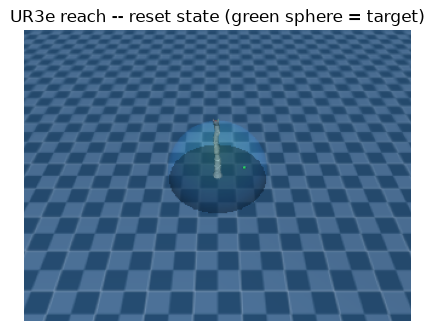

In [9]:
%matplotlib inline

play_cfg = load_env_cfg("Mjlab-UR3e-Reach", play=True)
play_cfg.scene.num_envs = 1
render_env = ManagerBasedRlEnv(play_cfg, device="cpu", render_mode="rgb_array")
render_env.reset()

frame = render_env.render()
plt.figure(figsize=(5, 4))
plt.imshow(frame)
plt.axis("off")
plt.title("UR3e reach -- reset state (green sphere = target)")
plt.show()

## 4. Run a short rollout

Random actions, just to see reset → step → reward/termination handling work end to
end before diving into the reward internals. `NUM_STEPS = 100` steps × `step_dt =
0.1s` (`decimation=10` × `timestep=0.01s`, from the settings table at the top) = 10
seconds of simulated time per environment.

`action = torch.randn(env.num_envs, action_dim) * 0.3` -- `torch.randn(4, 6)` draws
fresh, independent Gaussian noise (mean 0, std 1) for every environment and every one
of the 6 joints, *re-sampled from scratch on every step* (no correlation
step-to-step, so this isn't a smooth motion, just jitter). Multiplying by `0.3`
scales that down to std `0.3`, so most sampled values land in roughly `[-0.9, 0.9]`
-- combined with the action term's `0.08 rad` scale (see the naming reference
below), that works out to typical per-step joint deltas around `±0.024 rad`,
occasionally more. This is random, uncoordinated movement, not purposeful
reaching -- there's no trained policy involved yet, just noise exercising the
`reset` → `step` → reward/termination pipeline end to end.

Module mujoco_warp._src.derivative db4c283 load on device 'cpu' took 1.41 ms  (cached)


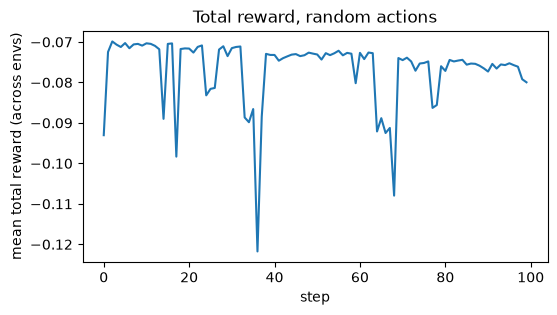

In [10]:
NUM_STEPS = 100
action_dim = env.action_manager.total_action_dim

total_reward_history = []
for _ in range(NUM_STEPS):
    action = torch.randn(env.num_envs, action_dim) * 0.3
    obs, reward, terminated, truncated, extras = env.step(action)
    total_reward_history.append(reward.mean().item())

plt.figure(figsize=(6, 3))
plt.plot(total_reward_history)
plt.xlabel("step")
plt.ylabel("mean total reward (across envs)")
plt.title("Total reward, random actions")
plt.show()

## 5. Reward functions — the part you actually want to tweak

Every reward term is a plain Python function `(env, **params) -> Tensor[num_envs]`,
registered by name with a weight in `_build_rewards()`:

| term | weight | what it does |
|---|---|---|
| [`reach_distance_reward`](ur3e_reach_env_cfg.py#L212) | `1.0` | negative distance from end-effector to target |
| [`success_bonus`](ur3e_reach_env_cfg.py#L220) | `1.0` | +1/step while within 3cm of target |
| [`settle_penalty`](ur3e_reach_env_cfg.py#L237) | `-0.5` | penalizes joint velocity, but *only* once close to the target |
| `mdp_rewards.action_rate_l2` | `-0.01` | built-in mjlab term; penalizes jerky actions |
| [`ee_speed_limit_penalty`](ur3e_reach_env_cfg.py#L266) | `-2.0` | hinge penalty above 0.12 m/s end-effector speed |
| [`joint_vel_limit_penalty`](ur3e_reach_env_cfg.py#L299) | `-1.5` | per-joint hinge penalty above 25% of the real UR3e's rated velocity |
| `mdp_rewards.joint_vel_l2` | `-0.001` | general smoothness regularizer |
| [`collision_cost`](ur3e_reach_env_cfg.py#L316) ×2 | `-1.0` each | self-collision / table-collision, from contact sensors |

All of them are assembled in one place:
**[`_build_rewards()` at `ur3e_reach_env_cfg.py:446`](ur3e_reach_env_cfg.py#L446)**.
That function is the single place to edit for a permanent change — add a dict entry,
change a `weight=`, or point `func=` at a new function.

The cells below do the same thing *live*, without touching the file, so you can see
the effect before committing anything to it.

### 5.1 Claude's Analysis of the Rewards

Checked against mjlab's own reference manipulation task
([`lift_cube_env_cfg.py`](../.venv/lib/python3.14/site-packages/mjlab/tasks/manipulation/lift_cube_env_cfg.py))
and its built-in reward library
([`mjlab/envs/mdp/rewards.py`](../.venv/lib/python3.14/site-packages/mjlab/envs/mdp/rewards.py)),
since this file's docstring says it was "restructured to match mjlab's own yam
lift_cube_env_cfg.py patterns." Short version: **mostly standard, a couple of
deliberately custom safety terms, and one plausible gap.**

**Directly standard / copied from mjlab's own reference:**

- `action_rate_l2` — identical term, identical weight (`-0.01`), literally the same
  call as lift_cube's.
- The **hinge-penalty-above-a-threshold** pattern (`ee_speed_limit`,
  `joint_vel_limit`) mirrors lift_cube's `joint_vel_hinge` almost exactly (same
  `max_vel`-cutoff idea), just split into two more granular versions (Cartesian EE
  speed *and* per-joint velocity) instead of lift_cube's one generic per-joint
  hinge.
- The **dense-shaping + precision-bonus** structure (`reach_distance` +
  `success_bonus`) mirrors lift_cube's `lift` + `lift_precise` pair -- same overall
  idea (reward getting closer, plus an extra bonus for being precisely there).

**One real difference from mjlab's own house style:** lift_cube's distance reward
uses a smooth exponential/Gaussian kernel (`reaching_std=0.2`, `bringing_std=0.3` --
reward saturates smoothly as distance -> 0). This task's `reach_distance` is a plain
negative-linear distance instead -- simpler and more "textbook," but less refined
than what mjlab itself tends to use. Worth trying the kernel version if you ever see
the policy overshoot/oscillate right at the success threshold.

**Custom, and reasonably so given this project's real-hardware goal** (not in
mjlab's reference, not typical of academic reach-task tutorials):

- `settle_penalty` — velocity penalty gated on proximity to target, encouraging the
  arm to actually stop and hold rather than oscillate through the goal. Not a
  standard named term anywhere, but a sensible trick.
- `ee_speed_limit_penalty` / `joint_vel_limit_penalty` (using the *real* UR3e's
  rated joint velocities) and `self_collision`/`table_collision` -- these are
  hardware-safety terms, not something you'd find in a pure-simulation benchmark.
  They make sense here specifically because section 1 already notes there's no
  early termination on collision, and this arm is meant to run on real hardware
  eventually.

**What mjlab's own reference includes that this task doesn't:** `joint_pos_limits`
-- lift_cube weights this heavily (`-10.0`) as a safety term, and it's in mjlab's
standard reward library, but there's no equivalent here. Given the small action
scale (`0.08 rad`/step) and safe home-pose reset it's probably not urgent, but for a
task explicitly aimed at real deployment, it's the one plausible gap worth
considering. `joint_torques_l2` (effort/energy regularization, also in the standard
library) is the other common omission, though the existing velocity/action-rate/
hinge terms already cover a lot of the same smoothness pressure, so that one's more
a judgment call than a gap.

In [11]:
print(f"{'term':<18}{'weight':>8}   params")
for name in env.reward_manager.active_terms:
    term_cfg = env.reward_manager.get_term_cfg(name)
    print(f"{name:<18}{term_cfg.weight:>8}   {term_cfg.params}")

term                weight   params
reach_distance         1.0   {'asset_cfg': SceneEntityCfg(name='ur3e', joint_names=None, joint_ids=slice(None, None, None), body_names=None, body_ids=slice(None, None, None), geom_names=None, geom_ids=slice(None, None, None), site_names=['end_effector'], site_ids=slice(None, None, None), actuator_names=None, actuator_ids=slice(None, None, None), tendon_names=None, tendon_ids=slice(None, None, None), camera_names=None, camera_ids=slice(None, None, None), light_names=None, light_ids=slice(None, None, None), material_names=None, material_ids=slice(None, None, None), pair_names=None, pair_ids=slice(None, None, None), preserve_order=False), 'command_name': 'reach_target'}
success_bonus          1.0   {'asset_cfg': SceneEntityCfg(name='ur3e', joint_names=None, joint_ids=slice(None, None, None), body_names=None, body_ids=slice(None, None, None), geom_names=None, geom_ids=slice(None, None, None), site_names=['end_effector'], site_ids=slice(None, None, None),

### A rollout helper that reports the per-term breakdown

`env.reward_manager.get_active_iterable_terms(env_idx)` returns each term's
**already-weighted** contribution to the reward, for one env, at the current step --
exactly what you want in order to see which term dominates at any given moment.

In [12]:
from mjlab.managers import RewardTermCfg
from ur3e.ur3e_reach_env_cfg import get_ur3e_reach_env_cfg


def make_ur3e_env(num_envs=4, reward_overrides=None, disable_terms=None,
                   extra_terms=None, **cfg_kwargs):
    """Build a fresh UR3e reach env, with optional reward tweaks layered on top
    of the file's defaults -- no need to edit ur3e_reach_env_cfg.py just to try
    something out.

    reward_overrides: {"term_name": new_weight}
    disable_terms:    ["term_name", ...]              -- fully removes the term
    extra_terms:      {"term_name": RewardTermCfg(...)} -- adds a new term
    """
    cfg = get_ur3e_reach_env_cfg(**cfg_kwargs)
    cfg.scene.num_envs = num_envs
    for name, weight in (reward_overrides or {}).items():
        cfg.rewards[name].weight = weight
    for name in (disable_terms or []):
        cfg.rewards.pop(name, None)
    cfg.rewards.update(extra_terms or {})
    return ManagerBasedRlEnv(cfg, device="cpu")


def rollout_with_reward_breakdown(env, num_steps=150, env_idx=0, action_scale=0.3):
    action_dim = env.action_manager.total_action_dim
    history = {name: [] for name in env.reward_manager.active_terms}
    distance_history = []
    reach_cmd = env.command_manager.get_term("reach_target")

    env.reset()
    for _ in range(num_steps):
        action = torch.randn(env.num_envs, action_dim) * action_scale
        env.step(action)
        for name, values in env.reward_manager.get_active_iterable_terms(env_idx):
            history[name].append(values[0])
        distance_history.append(reach_cmd.metrics["position_error"][env_idx].item())

    return history, distance_history


def plot_reward_breakdown(history, distance_history, title=""):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    for name, values in history.items():
        ax1.plot(values, label=name)
    ax1.set_ylabel("per-step reward contribution")
    ax1.legend(loc="upper right", fontsize=8, ncol=2)
    ax1.set_title(title or "Reward breakdown")

    ax2.plot(distance_history, color="black")
    ax2.axhline(0.03, color="green", linestyle="--", label="success threshold")
    ax2.set_ylabel("distance to target (m)")
    ax2.set_xlabel("step")
    ax2.legend()
    plt.tight_layout()
    plt.show()

### Baseline (no overrides)


+--------------------------------+
|        Base Environment        |
+------------------------+-------+
| Property               | Value |
+------------------------+-------+
| Number of environments | 4     |
| Environment device     | cpu   |
| Environment seed       | None  |
| Physics step-size      | 0.01  |
| Environment step-size  | 0.1   |
+------------------------+-------+

[INFO] <EventManager> contains 1 active terms.
+-------------------------------------+
| Active Event Terms in Mode: 'reset' |
+-------------+-----------------------+
|    Index    | Name                  |
+-------------+-----------------------+
|      0      | reset_arm             |
+-------------+-----------------------+

[INFO] <CommandManager> contains 1 active terms.
+---------------------------------------------+
|             Active Command Terms            |
+-------+--------------+----------------------+
| Index | Name         |         Type         |
+-------+--------------+--------------------

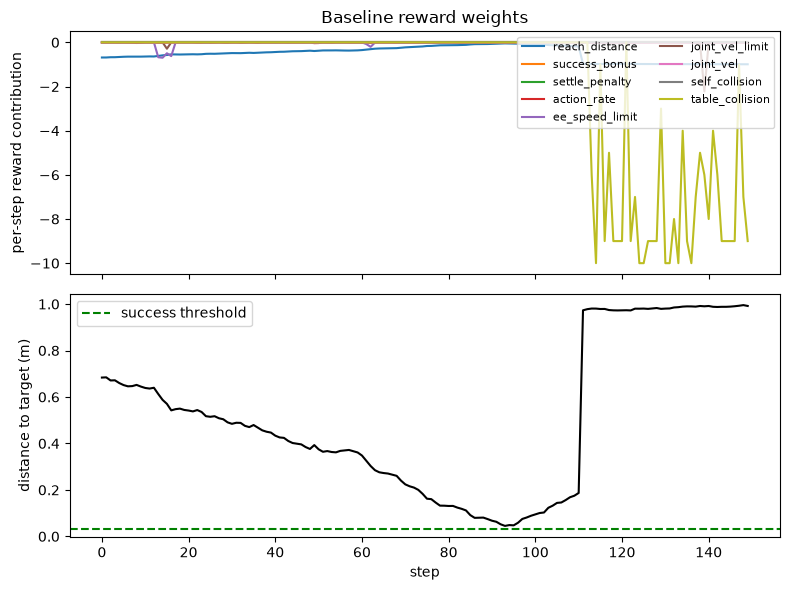

In [13]:
baseline_env = make_ur3e_env(num_envs=4)
history, distances = rollout_with_reward_breakdown(baseline_env)
plot_reward_breakdown(history, distances, title="Baseline reward weights")
baseline_env.close()

### Try it: change a weight

`reward_overrides` patches the config dict right before the env is built --
`ur3e_reach_env_cfg.py` is untouched.


+--------------------------------+
|        Base Environment        |
+------------------------+-------+
| Property               | Value |
+------------------------+-------+
| Number of environments | 4     |
| Environment device     | cpu   |
| Environment seed       | None  |
| Physics step-size      | 0.01  |
| Environment step-size  | 0.1   |
+------------------------+-------+

[INFO] <EventManager> contains 1 active terms.
+-------------------------------------+
| Active Event Terms in Mode: 'reset' |
+-------------+-----------------------+
|    Index    | Name                  |
+-------------+-----------------------+
|      0      | reset_arm             |
+-------------+-----------------------+

[INFO] <CommandManager> contains 1 active terms.
+---------------------------------------------+
|             Active Command Terms            |
+-------+--------------+----------------------+
| Index | Name         |         Type         |
+-------+--------------+--------------------

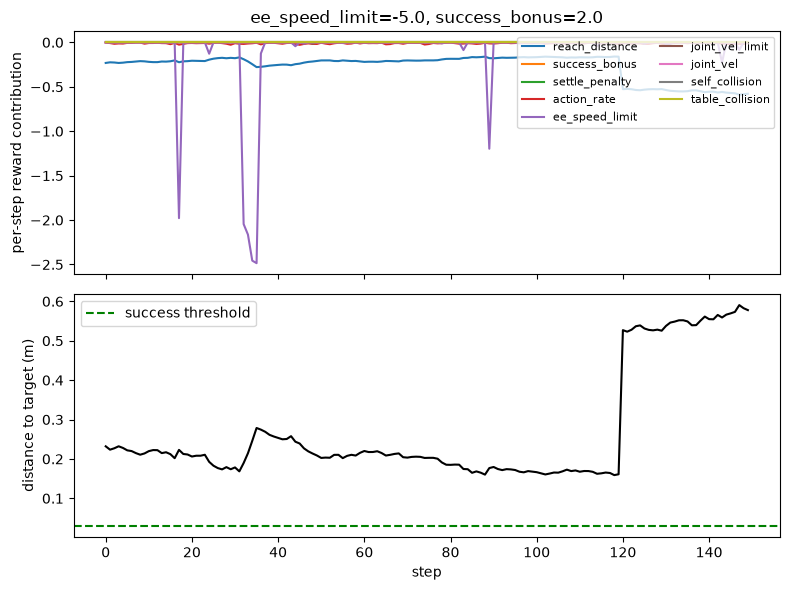

In [14]:
tuned_env = make_ur3e_env(
    num_envs=4,
    reward_overrides={
        "ee_speed_limit": -5.0,   # was -2.0 -- punish overspeed harder
        "success_bonus": 2.0,     # was 1.0  -- reward reaching more
    },
)
history, distances = rollout_with_reward_breakdown(tuned_env)
plot_reward_breakdown(history, distances, title="ee_speed_limit=-5.0, success_bonus=2.0")
tuned_env.close()

### Try it: add a brand-new reward term

Any reward function has the signature `(env, **params) -> Tensor[num_envs]`. Define
one inline and hand it to `extra_terms` as a `RewardTermCfg` -- no file edit needed
until you're happy with it and want to make it permanent.


+--------------------------------+
|        Base Environment        |
+------------------------+-------+
| Property               | Value |
+------------------------+-------+
| Number of environments | 4     |
| Environment device     | cpu   |
| Environment seed       | None  |
| Physics step-size      | 0.01  |
| Environment step-size  | 0.1   |
+------------------------+-------+

[INFO] <EventManager> contains 1 active terms.
+-------------------------------------+
| Active Event Terms in Mode: 'reset' |
+-------------+-----------------------+
|    Index    | Name                  |
+-------------+-----------------------+
|      0      | reset_arm             |
+-------------+-----------------------+

[INFO] <CommandManager> contains 1 active terms.
+---------------------------------------------+
|             Active Command Terms            |
+-------+--------------+----------------------+
| Index | Name         |         Type         |
+-------+--------------+--------------------

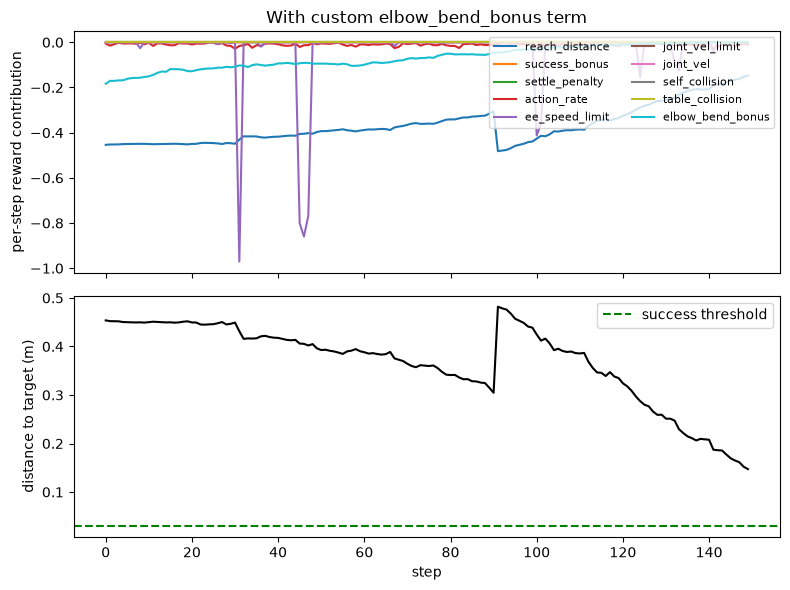

In [15]:
def elbow_bend_bonus(env, entity_name="ur3e", joint_name="elbow_joint", target_angle=-1.2):
    """Toy example: reward keeping the elbow near a preferred bend angle."""
    arm = env.scene[entity_name]
    idx = arm.joint_names.index(joint_name)
    joint_angle = arm.data.joint_pos[:, idx]
    return -torch.square(joint_angle - target_angle)


custom_env = make_ur3e_env(
    num_envs=4,
    extra_terms={
        "elbow_bend_bonus": RewardTermCfg(
            func=elbow_bend_bonus,
            weight=0.2,
            params={"joint_name": "elbow_joint", "target_angle": -1.2},
        ),
    },
)
print("reward terms now:", custom_env.reward_manager.active_terms)
history, distances = rollout_with_reward_breakdown(custom_env)
plot_reward_breakdown(history, distances, title="With custom elbow_bend_bonus term")
custom_env.close()

### Making a change permanent

Once you've found overrides you like, copy them into
[`_build_rewards()` in `ur3e_reach_env_cfg.py`](ur3e_reach_env_cfg.py#L446) (either
change an existing `weight=`, or add a new `RewardTermCfg` entry to the `rewards`
dict, same as `extra_terms` above). Restart this notebook's kernel (or
`importlib.reload` the module) afterwards so the registered task config picks up the
edit -- `import ur3e` only registers the task once per kernel session.

## 6. Training for real

This notebook's copy of the task (under `Simulations/ur3e/`) is a standalone package --
it's not wired into any project's CLI (command-line interface) entry points, so
`uv run train` won't see `Mjlab-UR3e-Reach` from here, and `Simulations/.venv` has no
`pyproject.toml` of its own to run `uv run` against in the first place.

The actual training/play CLI lives in **`my_mjlab_project`**, which lives *outside*
this repo entirely (it's a separate project, not tracked in this git repo, so there's
no "correct" path for it -- adjust the path below to wherever you keep your own copy).
On this machine it's at `~/Desktop/Summer26/MuJoCo/hackathon/my_mjlab_project` -- it
has `mjlab`'s `train`/`play` scripts and an RSL-RL PPO runner config already set up
for this task (see that project's own `src/my_mjlab_project/__init__.py`, which
registers it). Its `.venv` is a symlink back to this repo's `.venv` rather than its
own, so both stay on the same installed package versions. From that project's
directory:

```bash
cd path/to/your/my_mjlab_project
uv run train --task Mjlab-UR3e-Reach          # headless training
uv run play --task Mjlab-UR3e-Reach --agent trained   # watch a trained checkpoint
```

Careful: `uv run` there auto-syncs against *that* project's own `pyproject.toml` /
`uv.lock` (looser pins than this repo's, e.g. `mjlab>=1.5.0`), and since the `.venv`
is shared, a sync from there can change package versions this notebook depends on --
including the `mujoco-warp`/`warp-lang` pins called out in the Kernel section above.
Use `uv run --frozen` there if you want to skip that auto-sync.

One more thing to know before that works: that project's top-level `__init__.py`
currently has `#import my_mjlab_project.tasks.ur3e_reach` **commented out** (it's
focused on the `trailer_park` task right now) -- uncomment it to register the UR3e
task there too.

Any reward changes you've validated here need to be copied into that project's copy
of `ur3e_reach_env_cfg.py` too, since training reads from there, not from this
notebook's copy.

## 7. Cleanup

In [16]:
env.close()
render_env.close()

## 8. Moving to the Tufts HPC

Cloning this repo onto Tufts HPC (high-performance computing cluster) and running
`uv sync` gets you most of the way there, but there are a few HPC-specific snags
worth knowing about up front rather than debugging blind:

**1. `uv` itself and Python 3.14 need to be fetched — that needs internet access.**
`pyproject.toml` requires `python>=3.14`. `uv` downloads a matching Python build
automatically (Tufts doesn't need to have 3.14 as a module already), but that
download needs outbound internet. On most HPC clusters, only the **login node** has
internet access, not compute/GPU nodes — run `uv sync` on the login node, not inside
a Slurm (the cluster's job scheduler) job.

**2. `torch` pulls a full CUDA stack on Linux — mind your home-directory quota.**
`torch==2.12.1`'s Linux build has platform-gated dependencies that don't exist on a
Mac (see `uv.lock`, `marker = "sys_platform == 'linux'"`): `cuda-bindings`,
`cuda-toolkit` (with `cudart`, `cufft`, `cusolver`, etc.), `nvidia-cublas`,
`nvidia-cudnn`, `nvidia-nccl`, `nvidia-nvshmem`, `triton`. That's a genuinely large
download (multiple GB). Tufts home directories typically have a modest quota — point
`.venv`/uv's cache at scratch/research space instead of `$HOME`
(e.g. `export UV_CACHE_DIR=/cluster/tufts/.../uv-cache` and clone the repo itself
into scratch), or a sync can fill your quota partway through.

**3. Training itself needs a GPU-allocated node, not just wherever you ran `uv sync`.**
Installing CUDA-enabled `torch` doesn't grant you a GPU by itself — you still need
to request one via Slurm (e.g. `srun --gres=gpu:1 ...`) to actually train with CUDA.
This is the flip side of this Mac: here, `num_envs=512` runs on CPU because there's
no CUDA GPU at all (see the Environments section above); on Tufts, the same code
will actually use the GPU, but only inside a job that was granted one.

**4. Offscreen rendering (section 3 above) may need an explicit MuJoCo GL backend.**
`mujoco` depends on `glfw`/`pyopengl`, which normally expect a display. Headless HPC
nodes usually still work for `rgb_array` rendering, but sometimes need
`MUJOCO_GL=egl` (or `osmesa`) set explicitly so MuJoCo picks a headless-compatible
backend instead of trying to open a window. If the render call throws a GL/context
error, that environment variable is the first thing to try.

**5. Running the notebook itself** needs Tufts' Open OnDemand Jupyter, or SSH
port-forwarding, with the cloned `.venv` selected as the kernel — same
kernel-selection step as the Kernel section above, just pointed at the HPC path
instead of this Mac's.

Everything else (`mujoco-warp`, `warp-lang`, `mjlab` itself) already ships Linux
x86_64 wheels in `uv.lock`, so those resolve normally with no compilation needed.